In [1]:
%load_ext autoreload
%autoreload 2

from utils import Experiment

exp = Experiment()
exp.synth_data(n=100000, seed=5)

In [2]:
exp.df

feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,outcome,treatment,id
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64
0.441227,-0.33087,2.430771,-0.252092,0.10961,1.582481,-0.909232,-0.591637,0.187603,-0.32987,2.211177,0,0
-1.192765,-0.204877,-0.358829,0.603472,-1.664789,-0.700179,1.151391,1.857331,-1.51118,0.644848,-0.22383,0,1
-0.980608,-0.856853,-0.871879,-0.422508,0.99644,0.712421,0.059144,-0.363311,0.003289,-0.10593,3.247304,0,2
0.793053,-0.631572,-0.006195,-0.101068,-0.052308,0.249218,0.19766,1.334849,-0.086876,1.561532,-2.130129,1,3
-0.305853,-0.477731,0.100738,0.355438,0.269612,1.291963,1.139343,0.49444,-0.336336,-0.100614,-1.359424,0,4
…,…,…,…,…,…,…,…,…,…,…,…,…
-1.446671,-0.689478,-0.354746,2.485256,-0.351649,0.636044,-0.192531,0.467456,1.460077,0.488459,2.944922,0,99995
-0.663539,-0.34014,-0.164503,0.626933,-0.541467,-0.417807,0.678756,-0.180241,-0.185077,1.08051,-2.035539,0,99996
0.823675,0.489705,-0.379928,1.218187,-0.271683,0.675578,0.029155,1.202777,0.023097,0.230497,4.94335,0,99997


In [3]:
exp.user_condition("feature_1 > 0")

# Fit on P

In [4]:
%%time
exp.fit_tree(fit_on="P")

CPU times: user 600 ms, sys: 6.26 ms, total: 606 ms
Wall time: 619 ms


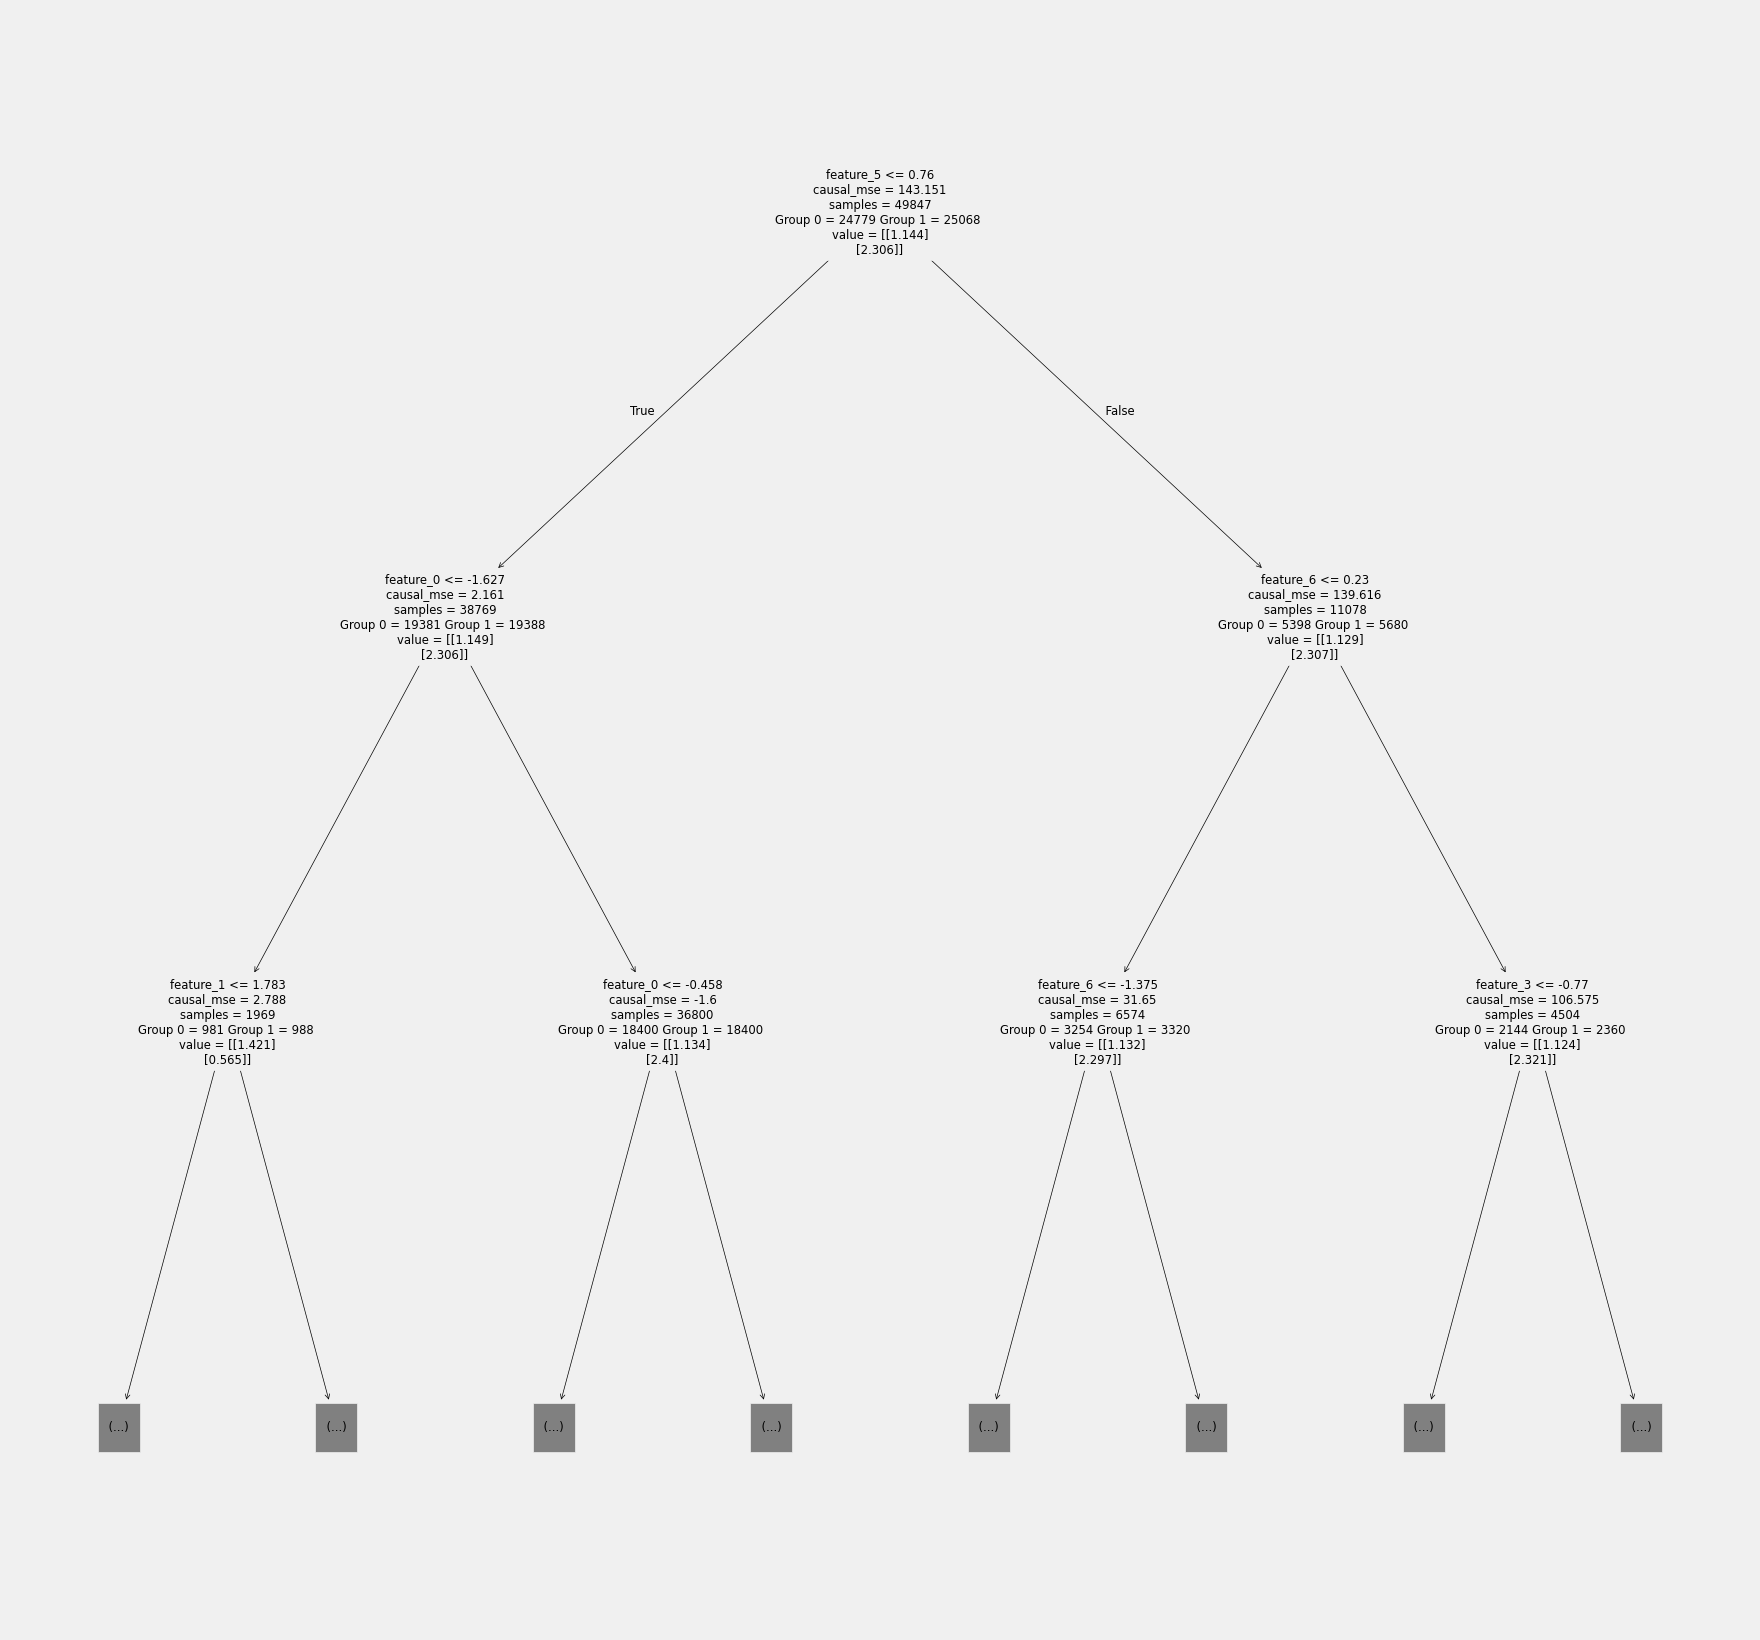

In [5]:
exp.plot_tree(max_depth=2)

In [6]:
exp.print_tree(max_depth=4)

Root CATE: 1.162
  feature_5 <= 0.76,  CATE: 1.157, distance: 0.78
    feature_5 <= 0.76 AND feature_0 <= -1.627,  CATE: -0.856, distance: 0.04
      feature_5 <= 0.76 AND feature_0 <= -1.627 AND feature_1 <= 1.783,  CATE: -1.006, distance: 0.04
        feature_5 <= 0.76 AND feature_0 <= -1.627 AND feature_1 <= 1.783 AND feature_6 <= 0.432,  CATE: -1.26, distance: 0.02
        feature_5 <= 0.76 AND feature_0 <= -1.627 AND feature_1 <= 1.783 AND feature_6 > 0.432,  CATE: -0.544, distance: 0.01
      feature_5 <= 0.76 AND feature_0 <= -1.627 AND feature_1 > 1.783,  CATE: 1.132, distance: 0.0
    feature_5 <= 0.76 AND feature_0 > -1.627,  CATE: 1.265, distance: 0.74
      feature_5 <= 0.76 AND feature_0 > -1.627 AND feature_0 <= -0.458,  CATE: 0.252, distance: 0.21
        feature_5 <= 0.76 AND feature_0 > -1.627 AND feature_0 <= -0.458 AND feature_1 <= 0.742,  CATE: -0.072, distance: 0.11
        feature_5 <= 0.76 AND feature_0 > -1.627 AND feature_0 <= -0.458 AND feature_1 > 0.742,  CAT

In [7]:
scores = exp.get_topK(k=10)
scores

Score mean: 0.5 ± 0.13
CATE mean: 1.53 ± 0.44
Distance mean: 0.3 ± 0.29
Depth: 2.9


,condition,cate,distance,T0,T1,depth,norm_cate,score
10,feature_5 <= 0.76 AND feature_0 > -1.627 AND f...,1.672,0.53,1.181418,2.853000,3,0.697539,0.630523
20,feature_5 > 0.76 AND feature_6 <= 0.23 AND fea...,2.397,0.04,1.158191,3.555371,4,1.000000,0.616000
12,feature_5 <= 0.76 AND feature_0 > -1.627 AND f...,2.200,0.16,1.571776,3.771497,4,0.917814,0.614688
6,feature_5 <= 0.76 AND feature_0 > -1.627,1.265,0.74,1.134108,2.399526,2,0.527743,0.612646
0,feature_5 <= 0.76,1.157,0.78,1.148625,2.306045,1,0.482687,0.601612
11,feature_5 <= 0.76 AND feature_0 > -1.627 AND f...,1.438,0.37,1.008863,2.446985,4,0.599917,0.507950
13,feature_5 > 0.76,1.178,0.22,1.128756,2.306902,1,0.491448,0.382869
24,feature_5 > 0.76 AND feature_6 > 0.23 AND feat...,1.431,0.01,0.592651,2.023732,4,0.596996,0.362198
18,feature_5 > 0.76 AND feature_6 <= 0.23 AND fea...,1.202,0.11,1.117496,2.319248,3,0.501460,0.344876
22,feature_5 > 0.76 AND feature_6 > 0.23 AND feat...,1.345,0.02,0.644495,1.989289,3,0.561118,0.344671


# Fit on D

In [8]:
%%time
exp.fit_tree(fit_on="D")

CPU times: user 1.49 s, sys: 12.2 ms, total: 1.5 s
Wall time: 1.55 s


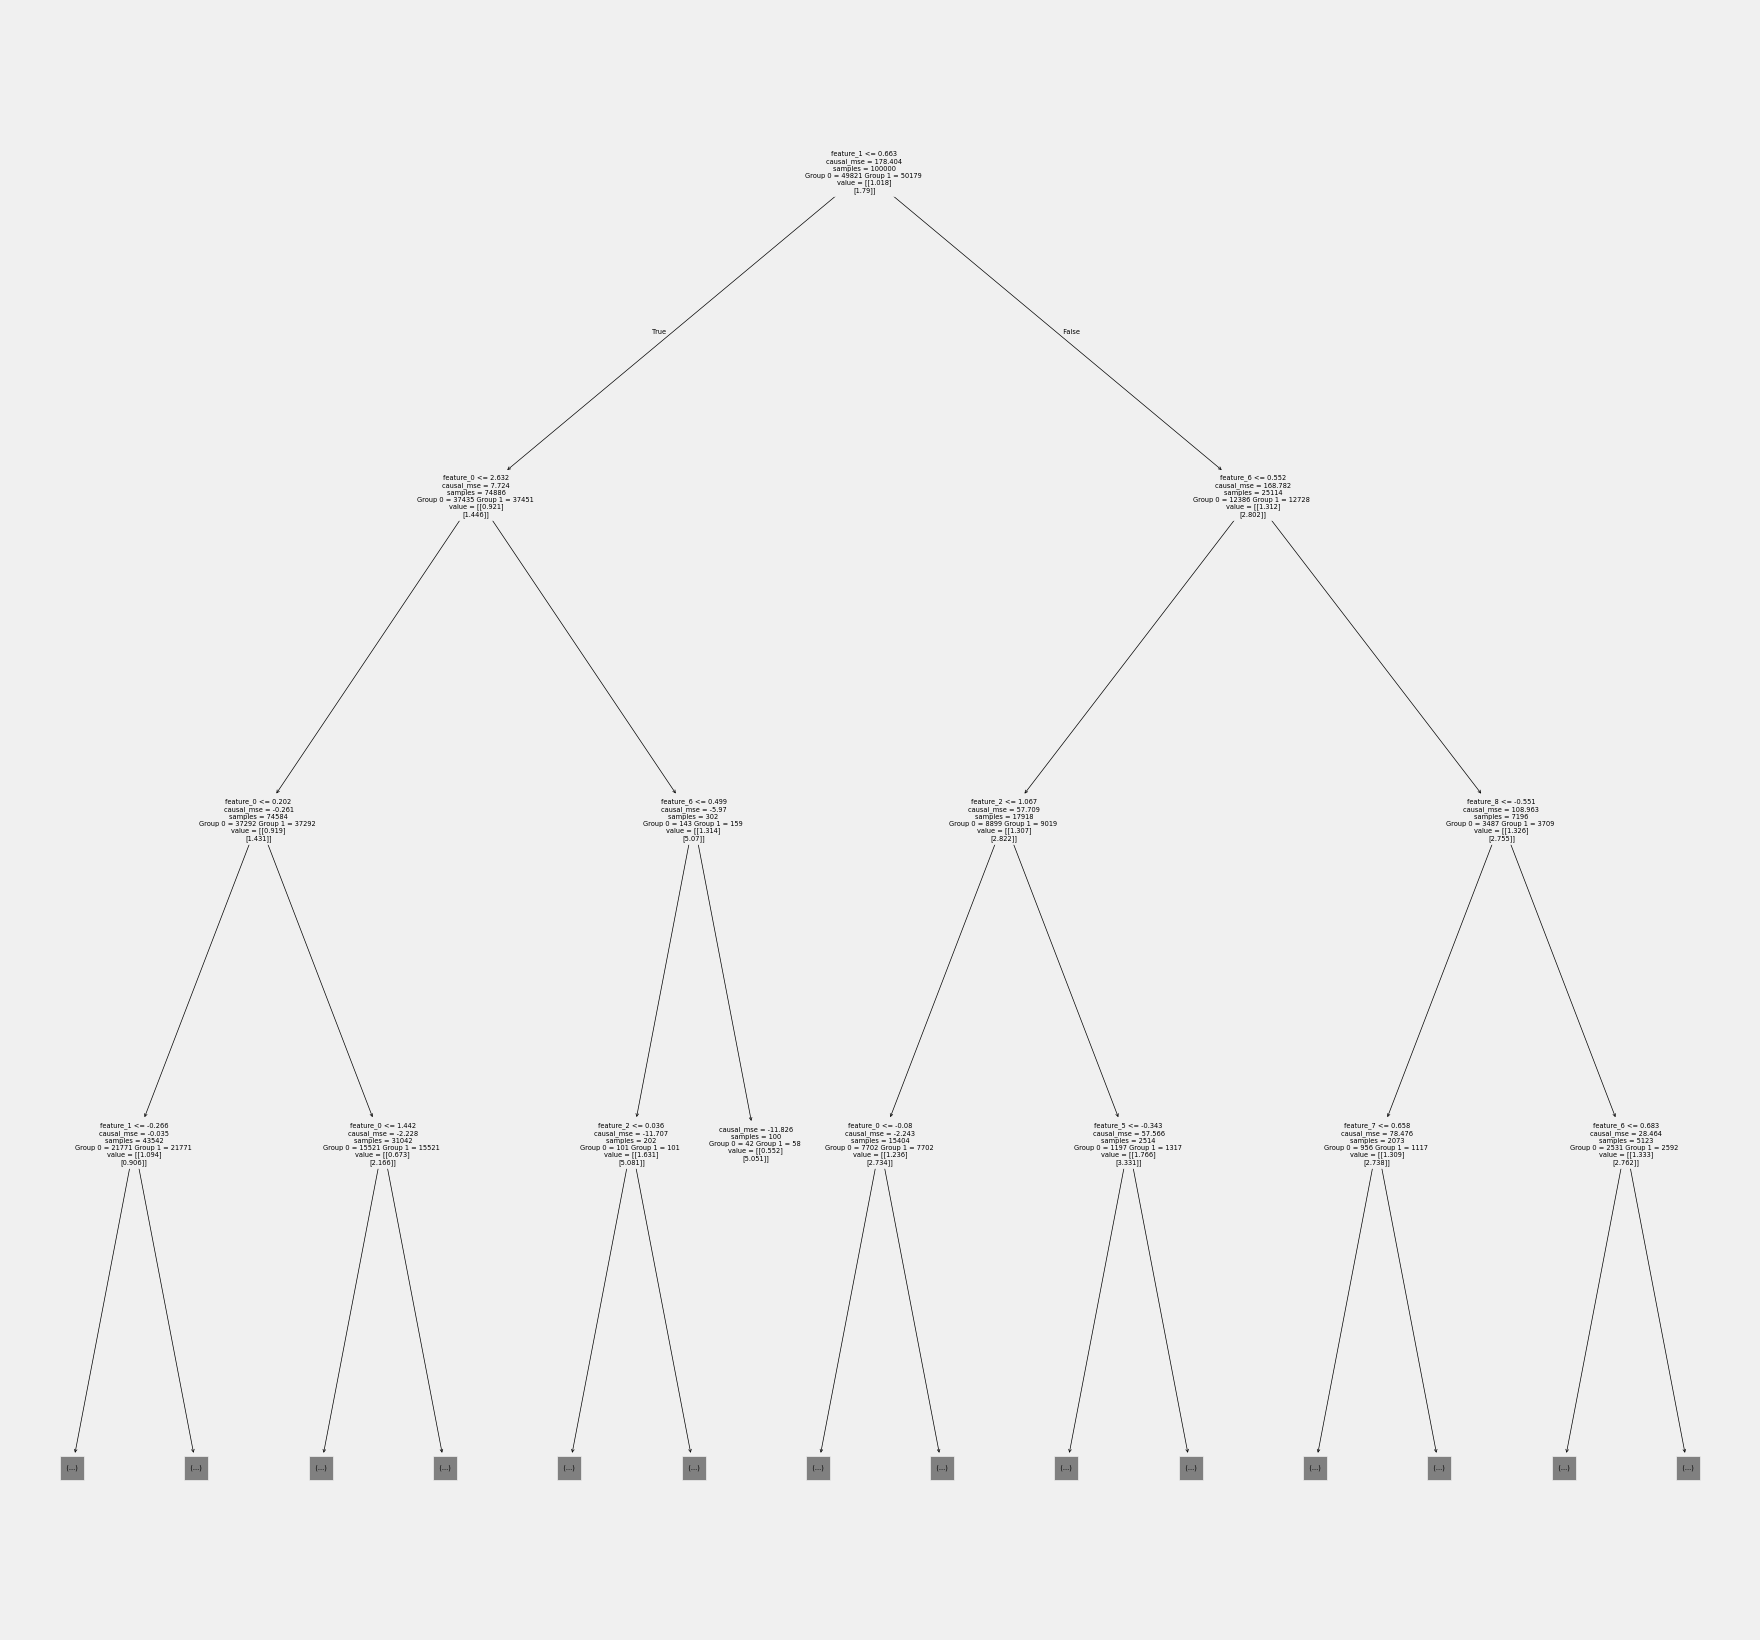

In [9]:
exp.plot_tree(max_depth=3)

In [10]:
exp.print_tree(max_depth=4)

Root CATE: 0.772
  feature_1 <= 0.663,  CATE: 0.525, distance: 0.5
    feature_1 <= 0.663 AND feature_0 <= 2.632,  CATE: 0.511, distance: 0.49
      feature_1 <= 0.663 AND feature_0 <= 2.632 AND feature_0 <= 0.202,  CATE: -0.188, distance: 0.29
        feature_1 <= 0.663 AND feature_0 <= 2.632 AND feature_0 <= 0.202 AND feature_1 <= -0.266,  CATE: -0.463, distance: 0.0
        feature_1 <= 0.663 AND feature_0 <= 2.632 AND feature_0 <= 0.202 AND feature_1 > -0.266,  CATE: 0.125, distance: 0.29
      feature_1 <= 0.663 AND feature_0 <= 2.632 AND feature_0 > 0.202,  CATE: 1.493, distance: 0.21
        feature_1 <= 0.663 AND feature_0 <= 2.632 AND feature_0 > 0.202 AND feature_0 <= 1.442,  CATE: 1.295, distance: 0.17
        feature_1 <= 0.663 AND feature_0 <= 2.632 AND feature_0 > 0.202 AND feature_0 > 1.442,  CATE: 2.451, distance: 0.04
    feature_1 <= 0.663 AND feature_0 > 2.632,  CATE: 3.755, distance: 0.0
      feature_1 <= 0.663 AND feature_0 > 2.632 AND feature_6 <= 0.499,  CATE: 3

In [11]:
exp.get_topK(k=10)

Score mean: 0.46 ± 0.07
CATE mean: 2.65 ± 1.24
Distance mean: 0.27 ± 0.33
Depth: 2.7


,condition,cate,distance,T0,T1,depth,norm_cate,score
40,feature_1 <= 0.663 AND feature_0 > 2.632 AND f...,4.499,0.00,0.552283,5.050824,3,1.000000,0.600000
39,feature_1 <= 0.663 AND feature_0 > 2.632 AND f...,4.073,0.00,1.203314,5.276525,4,0.905312,0.543187
36,feature_1 <= 0.663 AND feature_0 > 2.632,3.755,0.00,1.314180,5.069680,2,0.834630,0.500778
0,feature_5 <= 0.76,1.157,0.78,1.148625,2.306045,1,0.257168,0.466301
6,feature_5 <= 0.76 AND feature_0 > -1.627,1.265,0.74,1.134108,2.399526,2,0.281174,0.464704
37,feature_1 <= 0.663 AND feature_0 > 2.632 AND f...,3.449,0.00,1.631009,5.080508,3,0.766615,0.459969
10,feature_5 <= 0.76 AND feature_0 > -1.627 AND f...,1.672,0.53,1.181418,2.853000,3,0.371638,0.434983
41,feature_1 > 0.663,1.490,0.50,1.312483,2.802227,1,0.331185,0.398711
38,feature_1 <= 0.663 AND feature_0 > 2.632 AND f...,2.821,0.00,2.067257,4.888335,4,0.627028,0.376217
45,feature_1 > 0.663 AND feature_6 <= 0.552 AND f...,2.272,0.16,1.490497,3.762841,4,0.505001,0.367001
